In [1]:
!f2py -c rtp_test.f90 -m rtp_test

Cannot use distutils backend with Python>=3.12, using meson backend instead.
Using meson backend
Will pass --lower to f2py
See https://numpy.org/doc/stable/f2py/buildtools/meson.html
Reading fortran codes...
	Reading file 'rtp_test.f90' (format:free)
Post-processing...
	Block: rtp_test
			Block: rtp_store
In: :rtp_test:rtp_test.f90:rtp_store
param_eval: got "eval() arg 1 must be a string, bytes or code object" on 4
Applying post-processing hooks...
  character_backward_compatibility_hook
Post-processing (stage 2)...
Building modules...
    Building module "rtp_test"...
    Generating possibly empty wrappers"
    Maybe empty "rtp_test-f2pywrappers.f"
        Constructing wrapper function "rtp_store"...
          xstore,times = rtp_store(g,d2,dt,ens,n,ntimes,xstore,times)
    Wrote C/API module "rtp_test" to file "./rtp_testmodule.c"
The Meson build system
Version: 1.10.1
Source dir: /tmp/tmpkax56brz
Build dir: /tmp/tmpkax56brz/bbdir
Build type: native build
Project name: rtp_test
Projec

In [2]:
import os
os.listdir()

['.ipynb_checkpoints',
 'debug_build_rtp.py',
 'RTP2.ipynb',
 'rtp_test.cpython-312-x86_64-linux-gnu.so',
 'rtp_test.f90']

In [3]:
import rtp_test
print(rtp_test.rtp_store.__doc__)

xstore,times = rtp_store(g,d2,dt,ens,n,ntimes,xstore,times)

Wrapper for ``rtp_store``.

Parameters
----------
g : input float
d2 : input float
dt : input float
ens : input int
n : input int
ntimes : input int
xstore : input rank-2 array('f') with bounds (ens,ntimes)
times : input rank-1 array('f') with bounds (ntimes)

Returns
-------
xstore : rank-2 array('f') with bounds (ens,ntimes)
times : rank-1 array('f') with bounds (ntimes)



In [4]:
import numpy as np
import matplotlib.pyplot as plt

g = 0.05
d2 = 0.0
dt = 0.01
tmax = 300

ens = 10000
n = int(tmax/dt)

ntimes = 150

xstore = np.zeros((ens, ntimes), dtype=np.float32)
times = np.zeros(ntimes, dtype=np.float32)

xstore,times = rtp_test.rtp_store(g,d2,dt,ens,n,ntimes,xstore,times)

avgx2 = np.mean(xstore**2, axis=0)

In [5]:
avgx2 

array([3.7438765e+00, 1.4126948e+01, 2.9843451e+01, 4.9719013e+01,
       7.3231094e+01, 9.9645874e+01, 1.2843182e+02, 1.5926093e+02,
       1.9168092e+02, 2.2538480e+02, 2.6048889e+02, 2.9638651e+02,
       3.3290771e+02, 3.6959818e+02, 4.0696930e+02, 4.4462650e+02,
       4.8243390e+02, 5.2077979e+02, 5.6015430e+02, 6.0041687e+02,
       6.4062653e+02, 6.8003613e+02, 7.1874249e+02, 7.5750830e+02,
       7.9677570e+02, 8.3551617e+02, 8.7450610e+02, 9.1421600e+02,
       9.5421460e+02, 9.9424982e+02, 1.0338127e+03, 1.0738412e+03,
       1.1134766e+03, 1.1525580e+03, 1.1904230e+03, 1.2288289e+03,
       1.2670348e+03, 1.3054554e+03, 1.3433282e+03, 1.3811382e+03,
       1.4189584e+03, 1.4571519e+03, 1.4958329e+03, 1.5341271e+03,
       1.5729639e+03, 1.6114954e+03, 1.6506573e+03, 1.6901497e+03,
       1.7282769e+03, 1.7665924e+03, 1.8059229e+03, 1.8466780e+03,
       1.8875260e+03, 1.9278744e+03, 1.9682478e+03, 2.0080887e+03,
       2.0483779e+03, 2.0880728e+03, 2.1285796e+03, 2.1700220e

In [6]:
times

array([  2.,   4.,   6.,   8.,  10.,  12.,  14.,  16.,  18.,  20.,  22.,
        24.,  26.,  28.,  30.,  32.,  34.,  36.,  38.,  40.,  42.,  44.,
        46.,  48.,  50.,  52.,  54.,  56.,  58.,  60.,  62.,  64.,  66.,
        68.,  70.,  72.,  74.,  76.,  78.,  80.,  82.,  84.,  86.,  88.,
        90.,  92.,  94.,  96.,  98., 100., 102., 104., 106., 108., 110.,
       112., 114., 116., 118., 120., 122., 124., 126., 128., 130., 132.,
       134., 136., 138., 140., 142., 144., 146., 148., 150., 152., 154.,
       156., 158., 160., 162., 164., 166., 168., 170., 172., 174., 176.,
       178., 180., 182., 184., 186., 188., 190., 192., 194., 196., 198.,
       200., 202., 204., 206., 208., 210., 212., 214., 216., 218., 220.,
       222., 224., 226., 228., 230., 232., 234., 236., 238., 240., 242.,
       244., 246., 248., 250., 252., 254., 256., 258., 260., 262., 264.,
       266., 268., 270., 272., 274., 276., 278., 280., 282., 284., 286.,
       288., 290., 292., 294., 296., 298., 300.], d

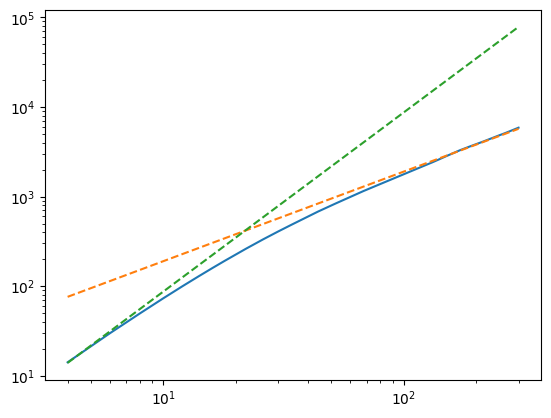

In [7]:
plt.loglog(times[1:], avgx2[1:], label=r"$\langle x^2 \rangle$")
plt.loglog(times[1:], 19*times[1:], "--", label="t")
plt.loglog(times[1:], 0.87*times[1:]**2, "--", label=r"$t^2$")

/tmp/ipykernel_11816/73517120.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


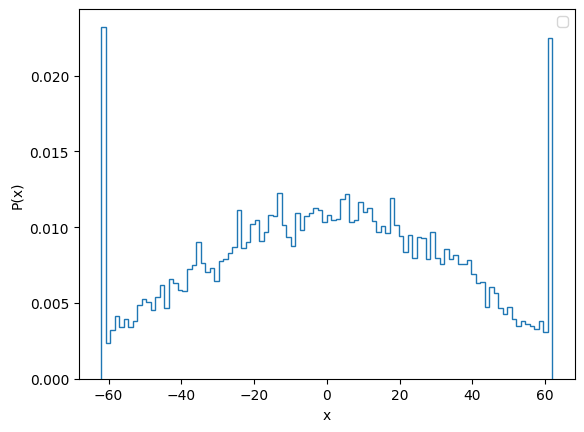

In [8]:
plt.hist(xstore[:,30], bins=100, density=True,
             histtype='step')

plt.xlabel("x")
plt.ylabel("P(x)")
plt.legend()
plt.show()